# 1. **Preparación del entorno**  

In [ ]:
#Librerías

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import statsmodels.api as sm

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from ipywidgets import interact, FloatSlider
from IPython.display import display
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller, kpss

# 2. **Carga de datos, índice temporal y frecuencia**  


In [ ]:
df = pd.read_csv('/content/datosserie.csv')
df["Fecha"] = pd.to_datetime(df["Fecha"])
df.set_index('Fecha', inplace=True)
df.sort_index(inplace=True)
df.drop_duplicates()
df.head()

,Latitud,Longitud,Humedad,Presion,Ruido,Temp,Gas_CO,Gas_NO2,Gas_O3,Gas_SO2,PM1,PM10,PM25
Fecha,,,,,,,,,,,,,
2020-09-01,18.461493,-69.930983,89.880491,100859.7135,60.691313,27.304638,0.249799,0.000081,0.0,0.035292,4.779851,42.41179,16.997761
2020-09-01,18.461493,-69.930983,89.880491,100859.7135,60.691313,27.304638,0.249799,0.000081,0.0,0.035292,4.779851,42.41179,16.997761
2020-09-01,18.461493,-69.930983,89.880491,100859.7135,60.691313,27.304638,0.249799,0.000081,0.0,0.035292,4.779851,42.41179,16.997761
2020-09-01,18.461493,-69.930983,89.880491,100859.7135,60.691313,27.304638,0.249799,0.000081,0.0,0.035292,4.779851,42.41179,16.997761
2020-09-01,18.461493,-69.930983,89.880491,100859.7135,60.691313,27.304638,0.249799,0.000081,0.0,0.035292,4.779851,42.41179,16.997761


In [ ]:
df = pd.read_csv('/content/serie_accion.csv')
df["fecha"] = pd.to_datetime(df["fecha"])
df.set_index('fecha', inplace=True)
df.sort_index(inplace=True)
df.head()

,precio
fecha,
2020-01-01,103.642889
2020-01-02,104.527937
2020-01-03,106.647514
2020-01-04,111.591736
2020-01-05,115.896571


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2178 entries, 2020-09-01 to 2021-01-01
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Latitud   2178 non-null   float64
 1   Longitud  2178 non-null   float64
 2   Humedad   2178 non-null   float64
 3   Presion   2178 non-null   float64
 4   Ruido     2178 non-null   float64
 5   Temp      2178 non-null   float64
 6   Gas_CO    2178 non-null   float64
 7   Gas_NO2   2178 non-null   float64
 8   Gas_O3    2178 non-null   float64
 9   Gas_SO2   2178 non-null   float64
 10  PM1       2178 non-null   float64
 11  PM10      2178 non-null   float64
 12  PM25      2178 non-null   float64
dtypes: float64(13)
memory usage: 238.2 KB


In [ ]:
freq = pd.infer_freq(df.index)
print(freq)

None


El resultado de la frecuencia es D, por lo tanto, la frecuencia del índice de la serie es diaria, ya que los datos van del 2020-01-01 al 2024-12-31 con entradas consecutivas.

# 3. **Análisis exploratorio (EDA)**  

In [ ]:
#Gráfico de línea

fig = go.Figure()

fig.add_trace(go.Scatter(x=df.index, y=df['PM10'],
                         mode='lines',
                         name='Cantidad de partículas PM10',
                         line=dict(color='green', width=2)))

fig.update_layout(
    title={
        'text': 'Cantidad de particulas medidas a lo largo del tiempo',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title='Fecha',
    yaxis_title='Precio',
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    template= 'seaborn'
)

fig.show()

In [ ]:
df['PM10'].describe().round(2)

,PM10
count,2178.00
mean,20.36
std,15.47
min,0.35
25%,9.91
50%,16.62
75%,27.68
max,75.74


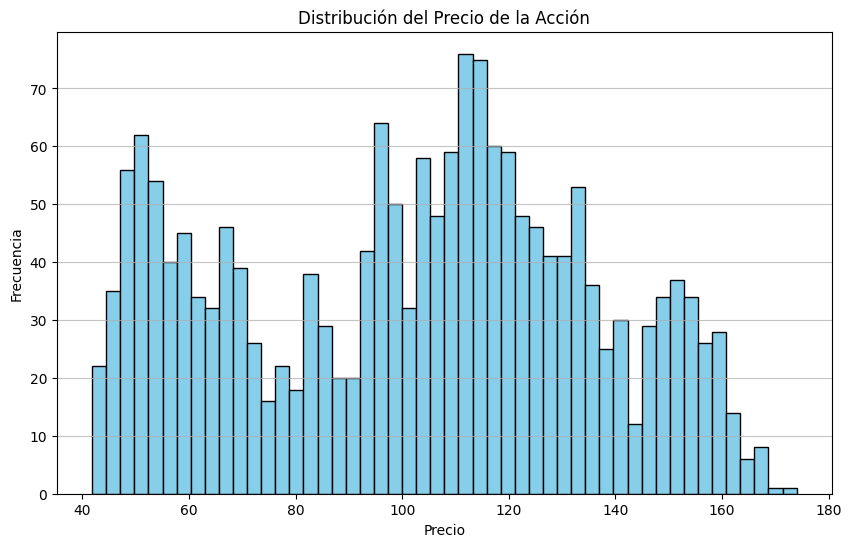

In [ ]:
# Histograma

plt.figure(figsize=(10, 6))
plt.hist(df['precio'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución del Precio de la Acción')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

En relación con las medidas de estadística básica, se observa que la variable 'precio' no presenta una distribución normal. Su comportamiento es multimodal, con al menos dos picos destacados en los intervalos de 50-60 y 110-120. Esto indica la posible existencia de diferentes grupos o categorías dentro de los datos. Además, la variable muestra una alta dispersión, lo que sugiere una amplia variabilidad en los valores de precio registrados.

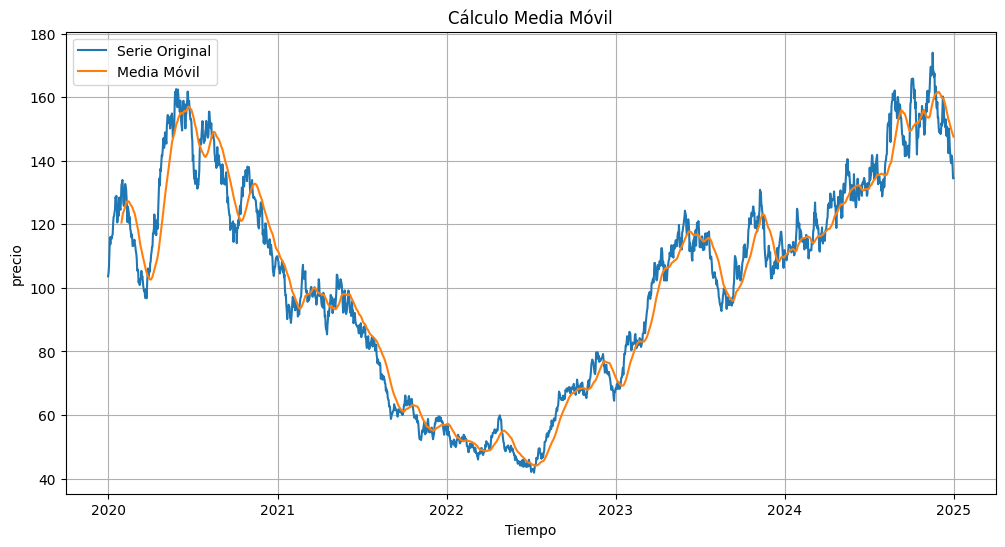

In [ ]:
# Media móvil

df['MediaMovil'] = df['precio'].rolling(window=30).mean() # Ajuste de 30 días

# Gráfica comparativa
plt.figure(figsize=(12, 6))

plt.plot(df['precio'], label='Serie Original')
plt.plot(df['MediaMovil'], label='Media Móvil')

plt.title('Cálculo Media Móvil')
plt.xlabel('Tiempo')
plt.ylabel('precio')
plt.legend()
plt.grid(True)
plt.show()

Existen varias tendencias a lo larga de la serie:

- Se observa una caída sostenida en el precio desde el 2020 hasta principios de 2022.

- A partir de 2022, el precio toca un mínimo y comienza a recuperarse. Se establece una tendencia alcista, que se mantiene con algunas oscilaciones.

- Se mantiene una tendencia alcista desde el 2023 y sostenida en el precio, alcanzando máximos en 2024.

# 4. **Descomposición de la serie**  

In [ ]:
# Modelo Aditivo

serie = df['PM10']

period = 365

decomp_add = seasonal_decompose(serie, model='additive', period=period)

rss_add = np.nansum(decomp_add.resid**2)

print(f"RSS aditivo:  {rss_add:.2f}")

RSS aditivo:  284289.76


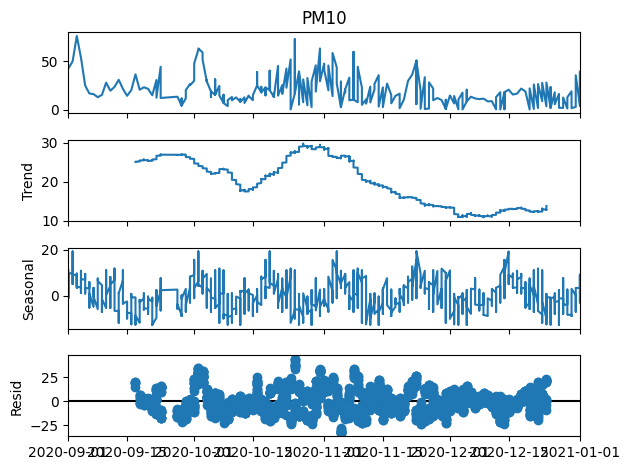

In [ ]:
decomp_add.plot()
plt.show()

In [ ]:
# Descomposición con el modelo sugerido
decomposition_final = seasonal_decompose(df['precio'], model='additive', period=365)

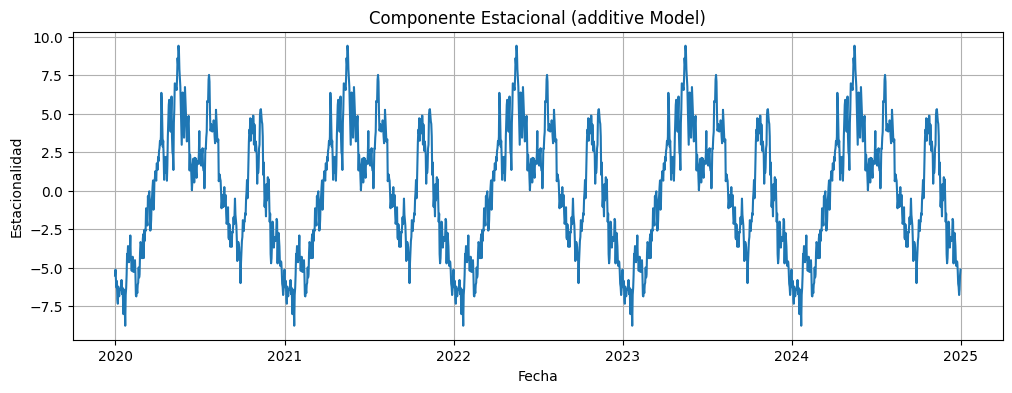

In [ ]:
# Graficar solo el componente estacional
plt.figure(figsize=(12, 4))
plt.plot(decomposition_final.seasonal)
plt.title(f'Componente Estacional (additive Model)')
plt.ylabel('Estacionalidad')
plt.xlabel('Fecha')
plt.grid(True)
plt.show()

Se ajusta el periodo a 365 de acuerdo a la frecuencia calculada anteriormente. Se evidencian claramente patrones de 12 meses, por lo tanto la estacionalidad es anual. Se aprecian valles al finalizar el año, y se llega al pico máximo en los primeros 4 meses del año. El componente estacional oscila aproximadamente entre -8 y +10, lo que indica que la estacionalidad puede aumentar o disminuir el precio en ese rango alrededor de la tendencia general.

# 5. **Pruebas de estacionariedad**

ADF Test
  Estadístico = -1.1783
  p-value     = 0.6829
  Valores críticos:
    1%: -3.4339
    5%: -2.8631
    10%: -2.5676

KPSS Test
  Estadístico = 1.6052
  p-value     = 0.0100
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

Ratio diario (serie_t / serie_{t-1}) – descripción:
count    1826.000000
mean        1.000337
std         0.019692
min         0.941366
25%         0.986760
50%         1.000173
75%         1.013049
max         1.066007
Name: precio, dtype: float64


/tmp/ipython-input-31-1351091115.py:15: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




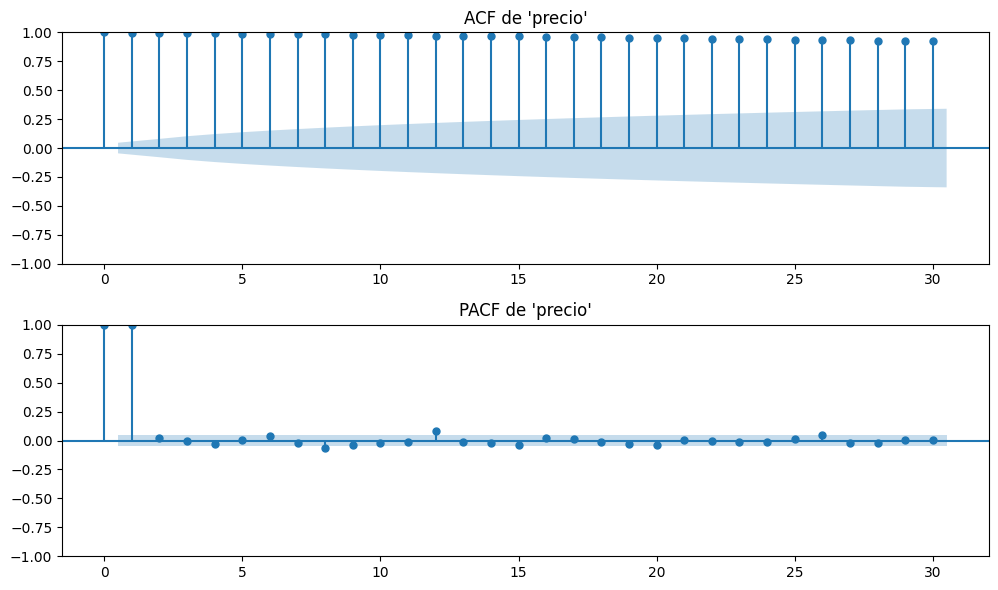

In [ ]:
#Pruebas ACF y PACF

serie = df['precio'].dropna()

#ADF test
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(serie)
print("ADF Test")
print(f"  Estadístico = {adf_stat:.4f}")
print(f"  p-value     = {adf_p:.4f}")
print("  Valores críticos:")
for nivel, val in adf_crit.items():
    print(f"    {nivel}: {val:.4f}")

#KPSS test
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie, regression='c')
print("\nKPSS Test")
print(f"  Estadístico = {kpss_stat:.4f}")
print(f"  p-value     = {kpss_p:.4f}")
print("  Valores críticos:")
for nivel, val in kpss_crit.items():
    print(f"    {nivel}: {val:.4f}")

# 3. Técnica manual: ratios día a día
ratio = serie / serie.shift(1)
print("\nRatio diario (serie_t / serie_{t-1}) – descripción:")
print(ratio.dropna().describe())

# 4. Gráficos de ACF y PACF
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(serie, lags=30, ax=axes[0], title="ACF de 'precio'")
plot_pacf(serie, lags=30, ax=axes[1], title="PACF de 'precio'")
plt.tight_layout()
plt.show()

Según los cálculos, el p value de la prueba ADF es 0.6829 y el p value de la prueba KPSS es de 0.0100. Teniendo en cuanta las reglas: (ADF = Si p-value ≥ 0.05 → no rechazamos H₀ → la serie no es estacionaria / KFSS = Si p-value < 0.05 → rechazamos H₀ → la serie no es estacionaria) podemos llegar a la conclusión que la serie no es estacionaria.


# 6. **Funciones de autocorrelación**  

7. **Funciones de autocorrelación**  
  - Grafica la **ACF** y la **PACF** de la serie original.  
  - Identifica visualmente:  
    - ¿Existe “cola larga” en la ACF?  
    - ¿En qué lag corta la PACF por primera vez?  

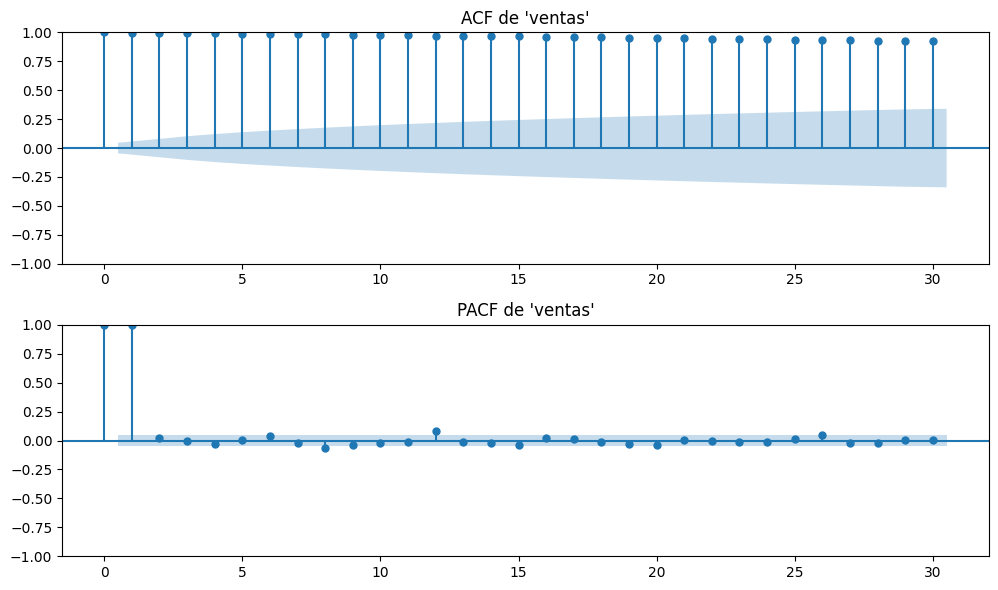

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(serie, lags=30, ax=axes[0], title="ACF de 'precio'")
plot_pacf(serie, lags=30, ax=axes[1], title="PACF de 'precio'")
plt.tight_layout()
plt.show()

¿Existe “cola larga” en la ACF?

Sí, se aprecia una cola larga en la ACF. Las barras de autocorrelación se mantienen altas y dentro del rango de confianza incluso después de muchos lags. Esto nos indica que hay una autocorrelación persistente en los datos, propio de series temporales no estacionarias.

¿En qué lag corta la PACF por primera vez?

Según el gráfico de PACF, la barra en el lag 1 es claramente más alta. Luego, a partir del lag 2, las barras caen dentro de la banda de confianza y se mantienen así. Por lo tanto, la PACF corta por primera vez en el lag 2.

Trabajando con series de tiempo y viendo el material de las clases, me parece que es una buena práctica abordar los componentes en un orden específico, para simplificar el análisis y a que cada parte del modelo funcione mejor.

El orden visto es: tendencia → estacionalidad → ruido.

- Tendencia:
Se analiza primero porque representa el comportamiento general de largo plazo. Nos permite ver si la serie está creciendo, disminuyendo o permaneciendo estable. Identificar la tendencia ayuda a entender la dirección principal que sigue la serie.

- Estacionalidad:
Una vez que se ha identificado la tendencia, se puede observar con más claridad la estacionalidad. Esta refleja los patrones que se repiten en intervalos regulares, como meses, estaciones o años. Analizar su frecuencia y amplitud nos permite entender cuándo se producen los cambios más predecibles dentro del ciclo, y qué tan fuertes son respecto a la media.

- Ruido:
Finalmente, el componente de ruido es lo que queda una vez que se han eliminado la tendencia y la estacionalidad. Este refleja las variaciones aleatorias y no sistemáticas que afectan la serie. Aunque no sigue un patrón claro, analizar su variabilidad nos permite estimar el nivel de incertidumbre que presentan los datos.



In [ ]:
df = df.drop_duplicates()
display(df.head())